# Checking correlation

In [1]:
from utils_3 import PairwiseData, Population

In [2]:
# import os

# os.environ["HF_HOME"] = "/home/jennifer/scratch/hf_datasets_cache"
# os.environ["HF_HUB_CACHE"] = "/home/jennifer/scratch/hf_datasets_cache"
# os.environ["HF_DATASETS_CACHE"] = "/home/jennifer/scratch/hf_datasets_cache"

In [3]:
import os
for k in ["HF_HOME", "HF_HUB_CACHE", "HF_DATASETS_CACHE", "XDG_CACHE_HOME"]:
    print(k, os.environ.get(k))

HF_HOME /home/jennifer/scratch/hf
HF_HUB_CACHE None
HF_DATASETS_CACHE /home/jennifer/scratch/hf/datasets
XDG_CACHE_HOME None


In [4]:
from datasets import load_dataset


ds = load_dataset(
    "lmarena-ai/arena-human-preference-140k") 
ds = dict(ds)

/home/jennifer/miniconda3/envs/ld/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating train split: 100%|██████████| 135634/135634 [00:23<00:00, 5764.94 examples/s] 


In [5]:
pw = PairwiseData(ds, M=30, N=20)

In [6]:
population = Population(pw)

100%|██████████| 20/20 [00:01<00:00, 15.86it/s]


20


/tmp/ipykernel_2694667/2072635279.py:20: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


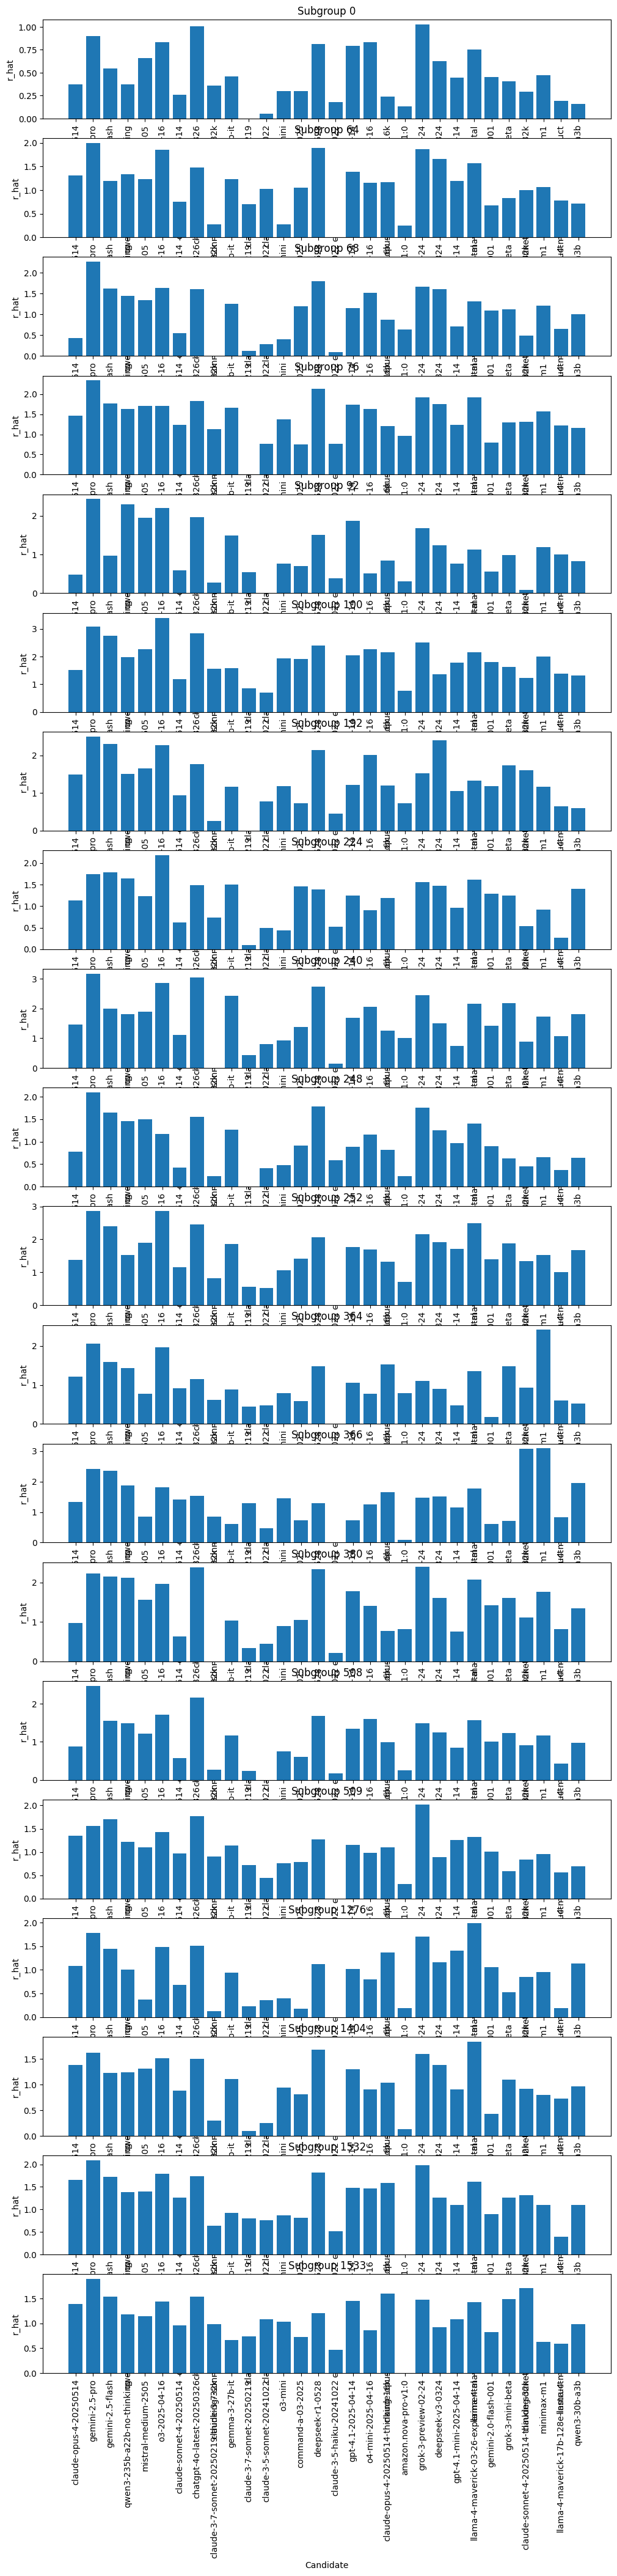

In [7]:
import numpy as np
import matplotlib.pyplot as plt

num_subgroups, num_candidates = population.population_utilities.shape
print(num_subgroups)
fig, axes = plt.subplots(num_subgroups, 1, figsize=(12, max(3, 2.5 * num_subgroups)), squeeze=False)
candidate_labels = [pw.idx_to_candidates[i] for i in range(num_candidates)]

for row_idx, ax in enumerate(axes[:, 0]):
    subgroup = population.idx_to_subgroup[row_idx]
    r_hat = population.population_utilities[row_idx]
    ax.bar(np.arange(num_candidates), r_hat)
    ax.set_title(f'Subgroup {subgroup}')
    ax.set_ylabel('r_hat')
    # ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


## Plotting the candidate distributions

In [8]:
pw.candidate_distr

array([0.04811053, 0.0455991 , 0.04537616, 0.04260244, 0.04232048,
       0.04203852, 0.03987463, 0.03695009, 0.03504193, 0.0344649 ,
       0.03350754, 0.03314033, 0.03152069, 0.03138955, 0.03136332,
       0.03077972, 0.03053055, 0.03048465, 0.03004531, 0.0300322 ,
       0.0290814 , 0.02855026, 0.02850436, 0.02828141, 0.02822895,
       0.02819617, 0.02704209, 0.02604539, 0.02557327, 0.02532409])

/tmp/ipykernel_2694667/275064710.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


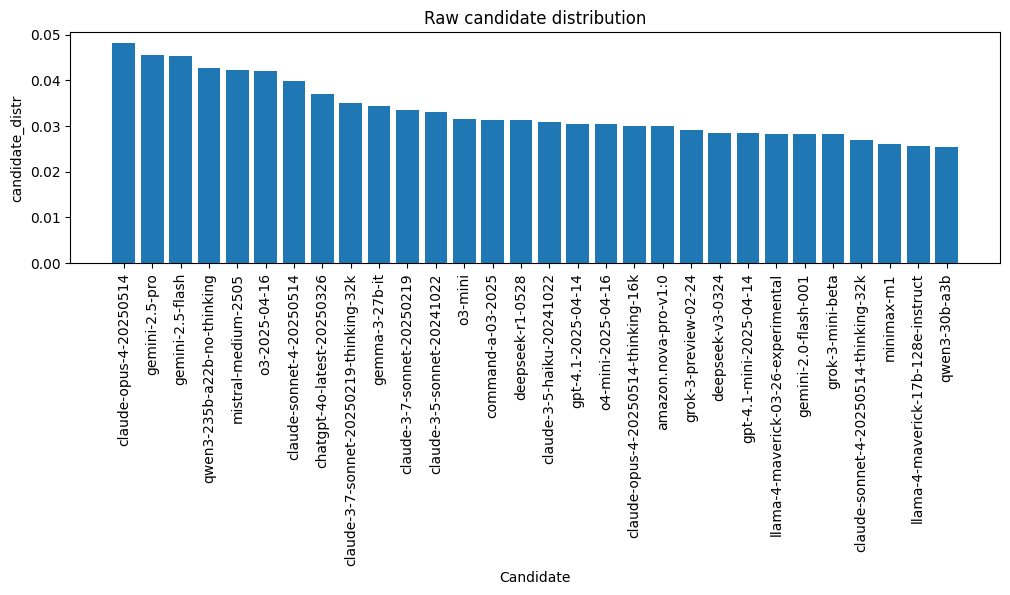

In [15]:
num_subgroups, num_candidates = population.population_utilities.shape
# print(num_subgroups)
fig, axes = plt.subplots(1, 1, figsize=(12, max(3, 2.5 * 1)), squeeze=False)
candidate_labels = [pw.idx_to_candidates[i] for i in range(num_candidates)]

for row_idx, ax in enumerate(axes[:, 0]):
    # subgroup = population.idx_to_subgroup[row_idx]
    # r_hat = population.population_utilities[row_idx]
    ax.bar(np.arange(num_candidates), pw.candidate_distr)
    ax.set_title(f'Raw candidate distribution')
    ax.set_ylabel('candidate_distr')
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


In [30]:
pw.candidate_distr.sum()

np.float64(0.9999999999999999)

The empirical distribution does sum to 1.0, approximately, which is what I would expect.

In [31]:
pw.winners.shape

(32735,)

In [32]:
conditional_idxs = pw.winners == 0.0

In [33]:
conditional_losers = pw.losers[conditional_idxs]

In [36]:
candidates

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])

In [37]:
candidates, counts = np.unique(
    conditional_losers,
    return_counts=True
)

all_conditional_distr = np.zeros_like(pw.candidate_distr)
all_conditional_distr[candidates] = counts / counts.sum()

/tmp/ipykernel_2694667/1793563913.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


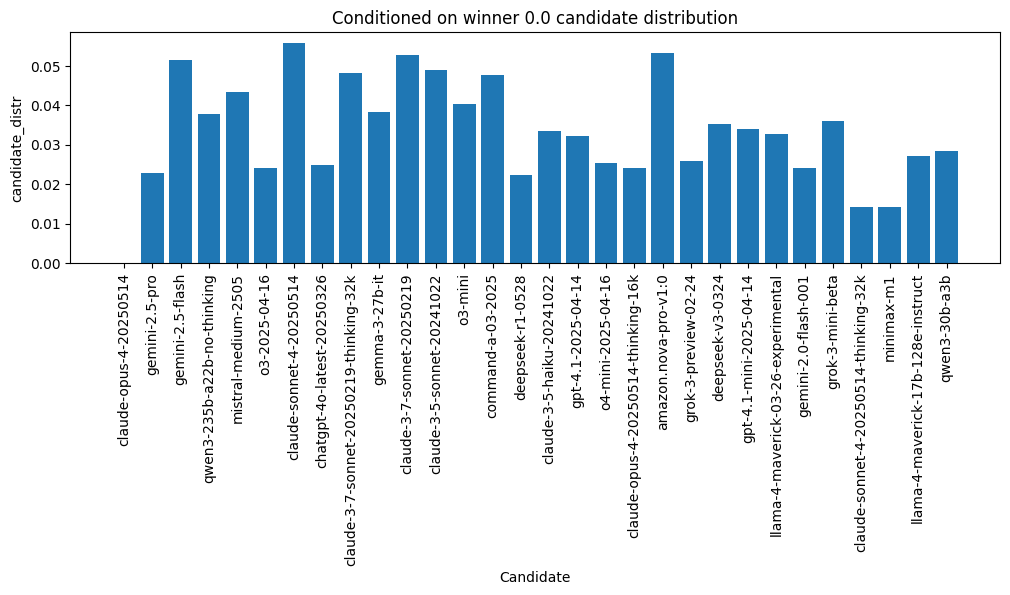

In [40]:
conditional_candidate_distr = counts / counts.sum()

num_candidates = len(all_conditional_distr)
# print(num_subgroups)
fig, axes = plt.subplots(1, 1, figsize=(12, max(3, 2.5 * 1)), squeeze=False)
candidate_labels = [pw.idx_to_candidates[i] for i in range(num_candidates)]

for row_idx, ax in enumerate(axes[:, 0]):
    # subgroup = population.idx_to_subgroup[row_idx]
    # r_hat = population.population_utilities[row_idx]
    ax.bar(np.arange(num_candidates), all_conditional_distr)
    ax.set_title(f'Conditioned on winner {0.0} candidate distribution')
    ax.set_ylabel('candidate_distr')
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


1.0
1.0
1.0
0.9999999999999998
0.9999999999999998
1.0
1.0
0.9999999999999998
1.0
1.0


/tmp/ipykernel_2694667/2804228249.py:37: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


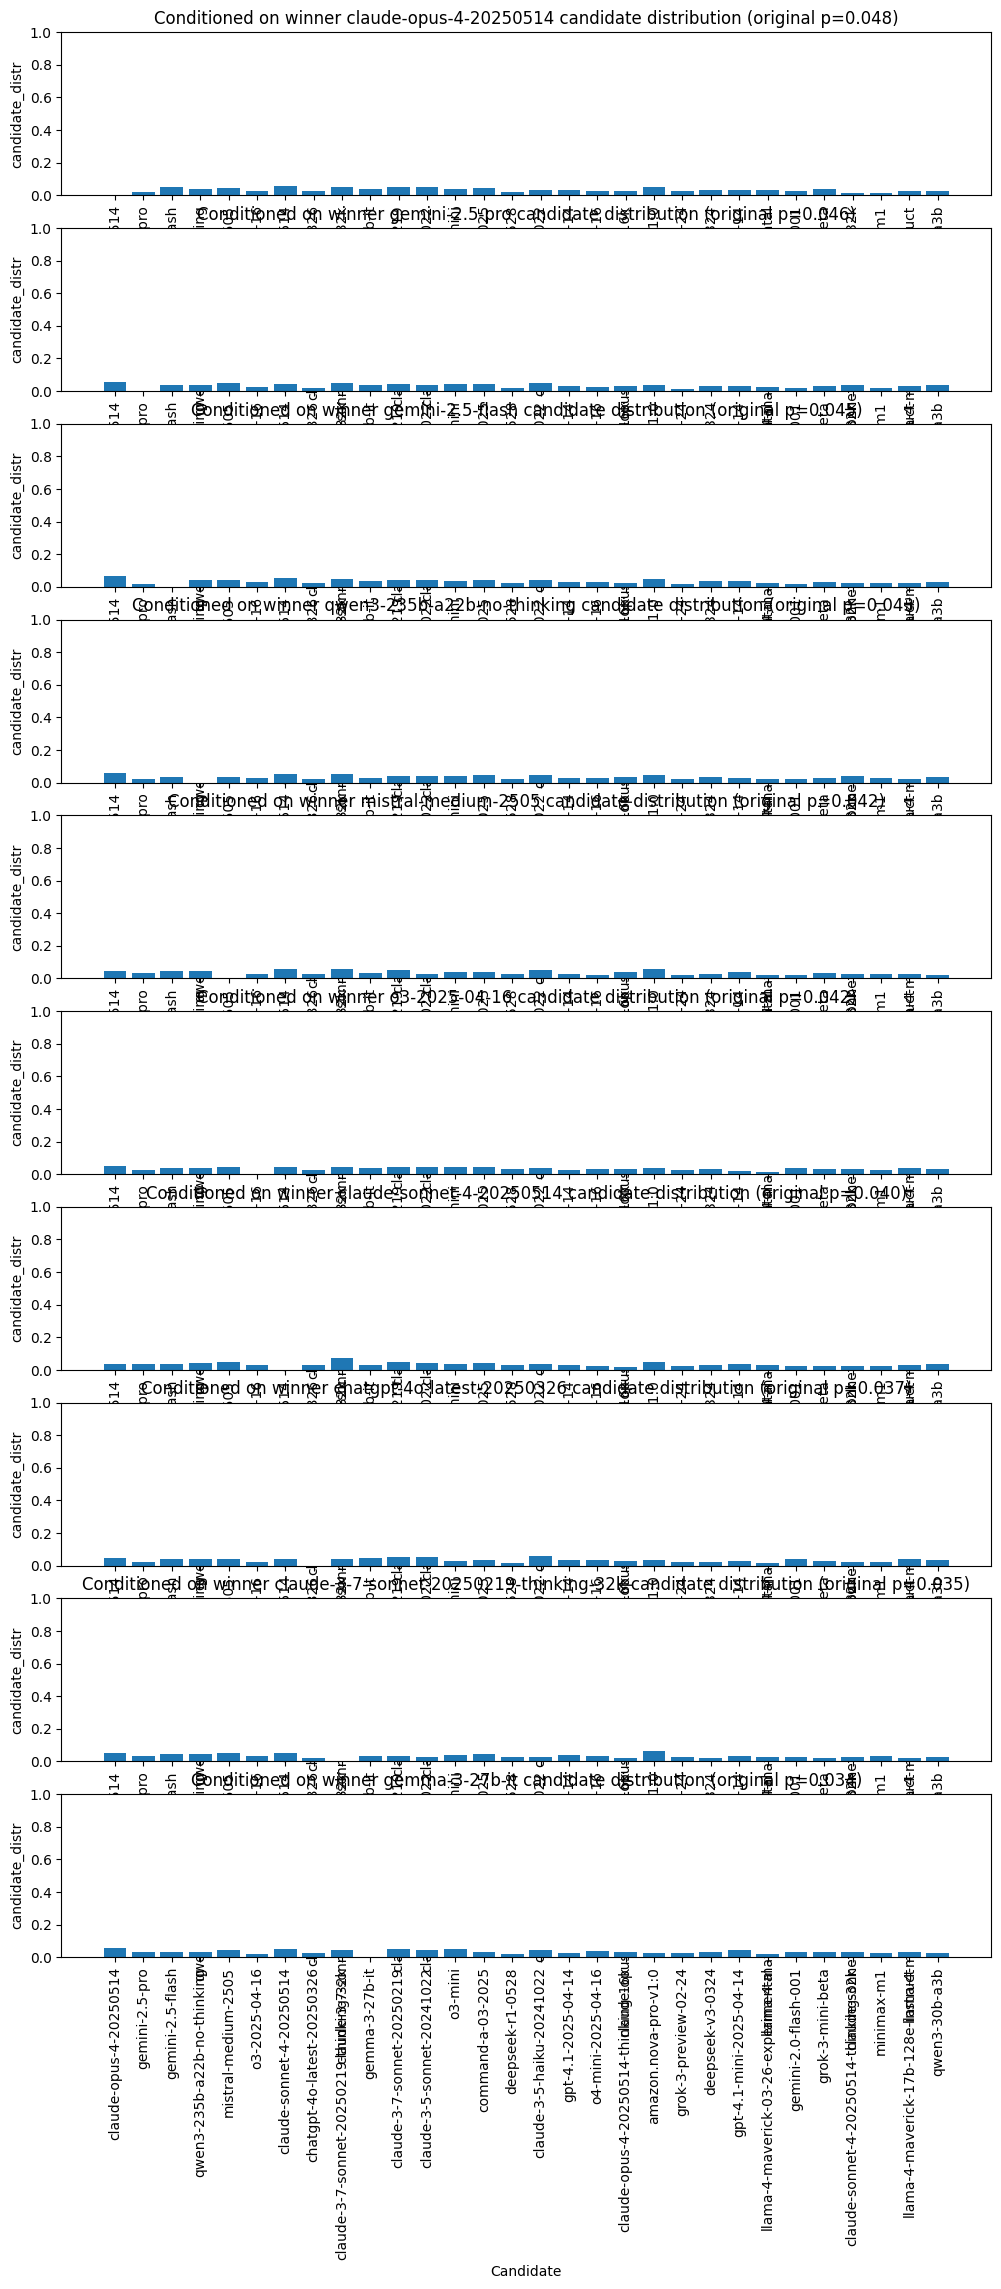

In [43]:
candidate_distribution = getattr(pw, 'candidate_distribution', pw.candidate_distr)
top_candidate_idxs = np.argsort(candidate_distribution)[-10:][::-1]

num_candidates = len(candidate_distribution)
candidate_labels = [pw.idx_to_candidates[i] for i in range(num_candidates)]
top_candidate_labels = [pw.idx_to_candidates[i] for i in top_candidate_idxs]

fig, axes = plt.subplots(
    len(top_candidate_idxs),
    1,
    figsize=(12, max(3, 2.5 * len(top_candidate_idxs))),
    squeeze=False,
)

for row_idx, (winner_idx, winner_label) in enumerate(zip(top_candidate_idxs, top_candidate_labels)):
    conditional_idxs = pw.winners == winner_idx
    conditional_losers = pw.losers[conditional_idxs]

    all_conditional_distr = np.zeros_like(candidate_distribution)
    if len(conditional_losers) > 0:
        candidates, counts = np.unique(conditional_losers, return_counts=True)
        all_conditional_distr[candidates] = counts / counts.sum()

    ax = axes[row_idx, 0]
    ax.bar(np.arange(num_candidates), all_conditional_distr)
    ax.set_title(
        f'Conditioned on winner {winner_label} candidate distribution '
        f'(original p={candidate_distribution[winner_idx]:.3f})'
    )
    ax.set_ylabel('candidate_distr')
    ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(num_candidates))
    ax.set_xticklabels(candidate_labels, rotation=90)
    print(all_conditional_distr.sum())

axes[-1, 0].set_xlabel('Candidate')
plt.tight_layout()
plt.show()


In [44]:
from scipy.stats import chi2_contingency

candidate_distribution = getattr(pw, 'candidate_distribution', pw.candidate_distr)
top_candidate_idxs = np.argsort(candidate_distribution)[-10:][::-1]

num_candidates = len(candidate_distribution)
candidate_labels = np.array([pw.idx_to_candidates[i] for i in range(num_candidates)])
top_candidate_labels = np.array([pw.idx_to_candidates[i] for i in top_candidate_idxs])

# Rows are the top-10 winner candidates; columns are loser/candidate frequencies.
contingency = np.zeros((len(top_candidate_idxs), num_candidates), dtype=int)
for row_idx, winner_idx in enumerate(top_candidate_idxs):
    loser_idxs = pw.losers[pw.winners == winner_idx]
    candidates, counts = np.unique(loser_idxs, return_counts=True)
    contingency[row_idx, candidates] = counts

# Drop rows/columns with no observations; scipy's expected-count table cannot contain zeros.
row_mask = contingency.sum(axis=1) > 0
col_mask = contingency.sum(axis=0) > 0
observed = contingency[row_mask][:, col_mask]
observed_winner_labels = top_candidate_labels[row_mask]
observed_candidate_labels = candidate_labels[col_mask]

chi2, p_value, dof, expected = chi2_contingency(observed)
standardized_residuals = (observed - expected) / np.sqrt(expected)

print('Chi-square test of independence')
print(f'rows: {observed.shape[0]} winner candidates')
print(f'columns: {observed.shape[1]} loser candidates with nonzero counts')
print(f'n: {observed.sum()}')
print(f'chi2: {chi2:.4f}')
print(f'dof: {dof}')
print(f'p-value: {p_value:.4g}')
print('reject independence at alpha=0.05:', p_value < 0.05)

print('\nWinner rows:')
for i, label in enumerate(observed_winner_labels):
    print(f'{i}: {label} (n={observed[i].sum()})')

print('\nLoser candidate columns:')
for i, label in enumerate(observed_candidate_labels):
    print(f'{i}: {label} (n={observed[:, i].sum()})')

# Inspect these arrays directly for the observed counts, expected counts under independence,
# and the cells contributing most strongly to the chi-square statistic.
observed, expected, standardized_residuals


Chi-square test of independence
rows: 10 winner candidates
columns: 30 loser candidates with nonzero counts
n: 14858
chi2: 989.4653
dof: 261
p-value: 2.75e-85
reject independence at alpha=0.05: True

Winner rows:
0: claude-opus-4-20250514 (n=1614)
1: gemini-2.5-pro (n=2128)
2: gemini-2.5-flash (n=1816)
3: qwen3-235b-a22b-no-thinking (n=1532)
4: mistral-medium-2505 (n=1535)
5: o3-2025-04-16 (n=1643)
6: claude-sonnet-4-20250514 (n=1133)
7: chatgpt-4o-latest-20250326 (n=1499)
8: claude-3-7-sonnet-20250219-thinking-32k (n=836)
9: gemma-3-27b-it (n=1122)

Loser candidate columns:
0: claude-opus-4-20250514 (n=707)
1: gemini-2.5-pro (n=330)
2: gemini-2.5-flash (n=526)
3: qwen3-235b-a22b-no-thinking (n=534)
4: mistral-medium-2505 (n=595)
5: o3-2025-04-16 (n=356)
6: claude-sonnet-4-20250514 (n=679)
7: chatgpt-4o-latest-20250326 (n=321)
8: claude-3-7-sonnet-20250219-thinking-32k (n=696)
9: gemma-3-27b-it (n=483)
10: claude-3-7-sonnet-20250219 (n=688)
11: claude-3-5-sonnet-20241022 (n=623)
12: o3

(array([[  0,  37,  83,  61,  70,  39,  90,  40,  78,  62,  85,  79,  65,
          77,  36,  54,  52,  41,  39,  86,  42,  57,  55,  53,  39,  58,
          23,  23,  44,  46],
        [121,   0,  81,  80, 112,  53,  93,  46, 110,  74,  91,  81,  88,
          98,  45, 101,  63,  50,  61,  85,  33,  65,  70,  50,  45,  72,
          74,  46,  64,  76],
        [122,  34,   0,  78,  77,  58,  95,  42,  89,  67,  81,  82,  66,
          80,  41,  79,  59,  55,  46,  83,  29,  65,  66,  41,  34,  52,
          45,  46,  48,  56],
        [ 95,  32,  55,   0,  55,  41,  82,  30,  78,  40,  64,  59,  62,
          71,  36,  70,  47,  48,  51,  75,  38,  55,  43,  34,  36,  39,
          63,  46,  35,  52],
        [ 71,  48,  68,  71,   0,  43,  87,  37,  86,  47,  77,  44,  57,
          60,  44,  82,  39,  28,  57,  85,  29,  39,  62,  34,  30,  51,
          44,  37,  42,  36],
        [ 80,  39,  63,  63,  70,   0,  74,  40,  70,  58,  74,  76,  76,
          75,  48,  60,  43,  50,  5

/tmp/ipykernel_2694667/3502448588.py:21: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


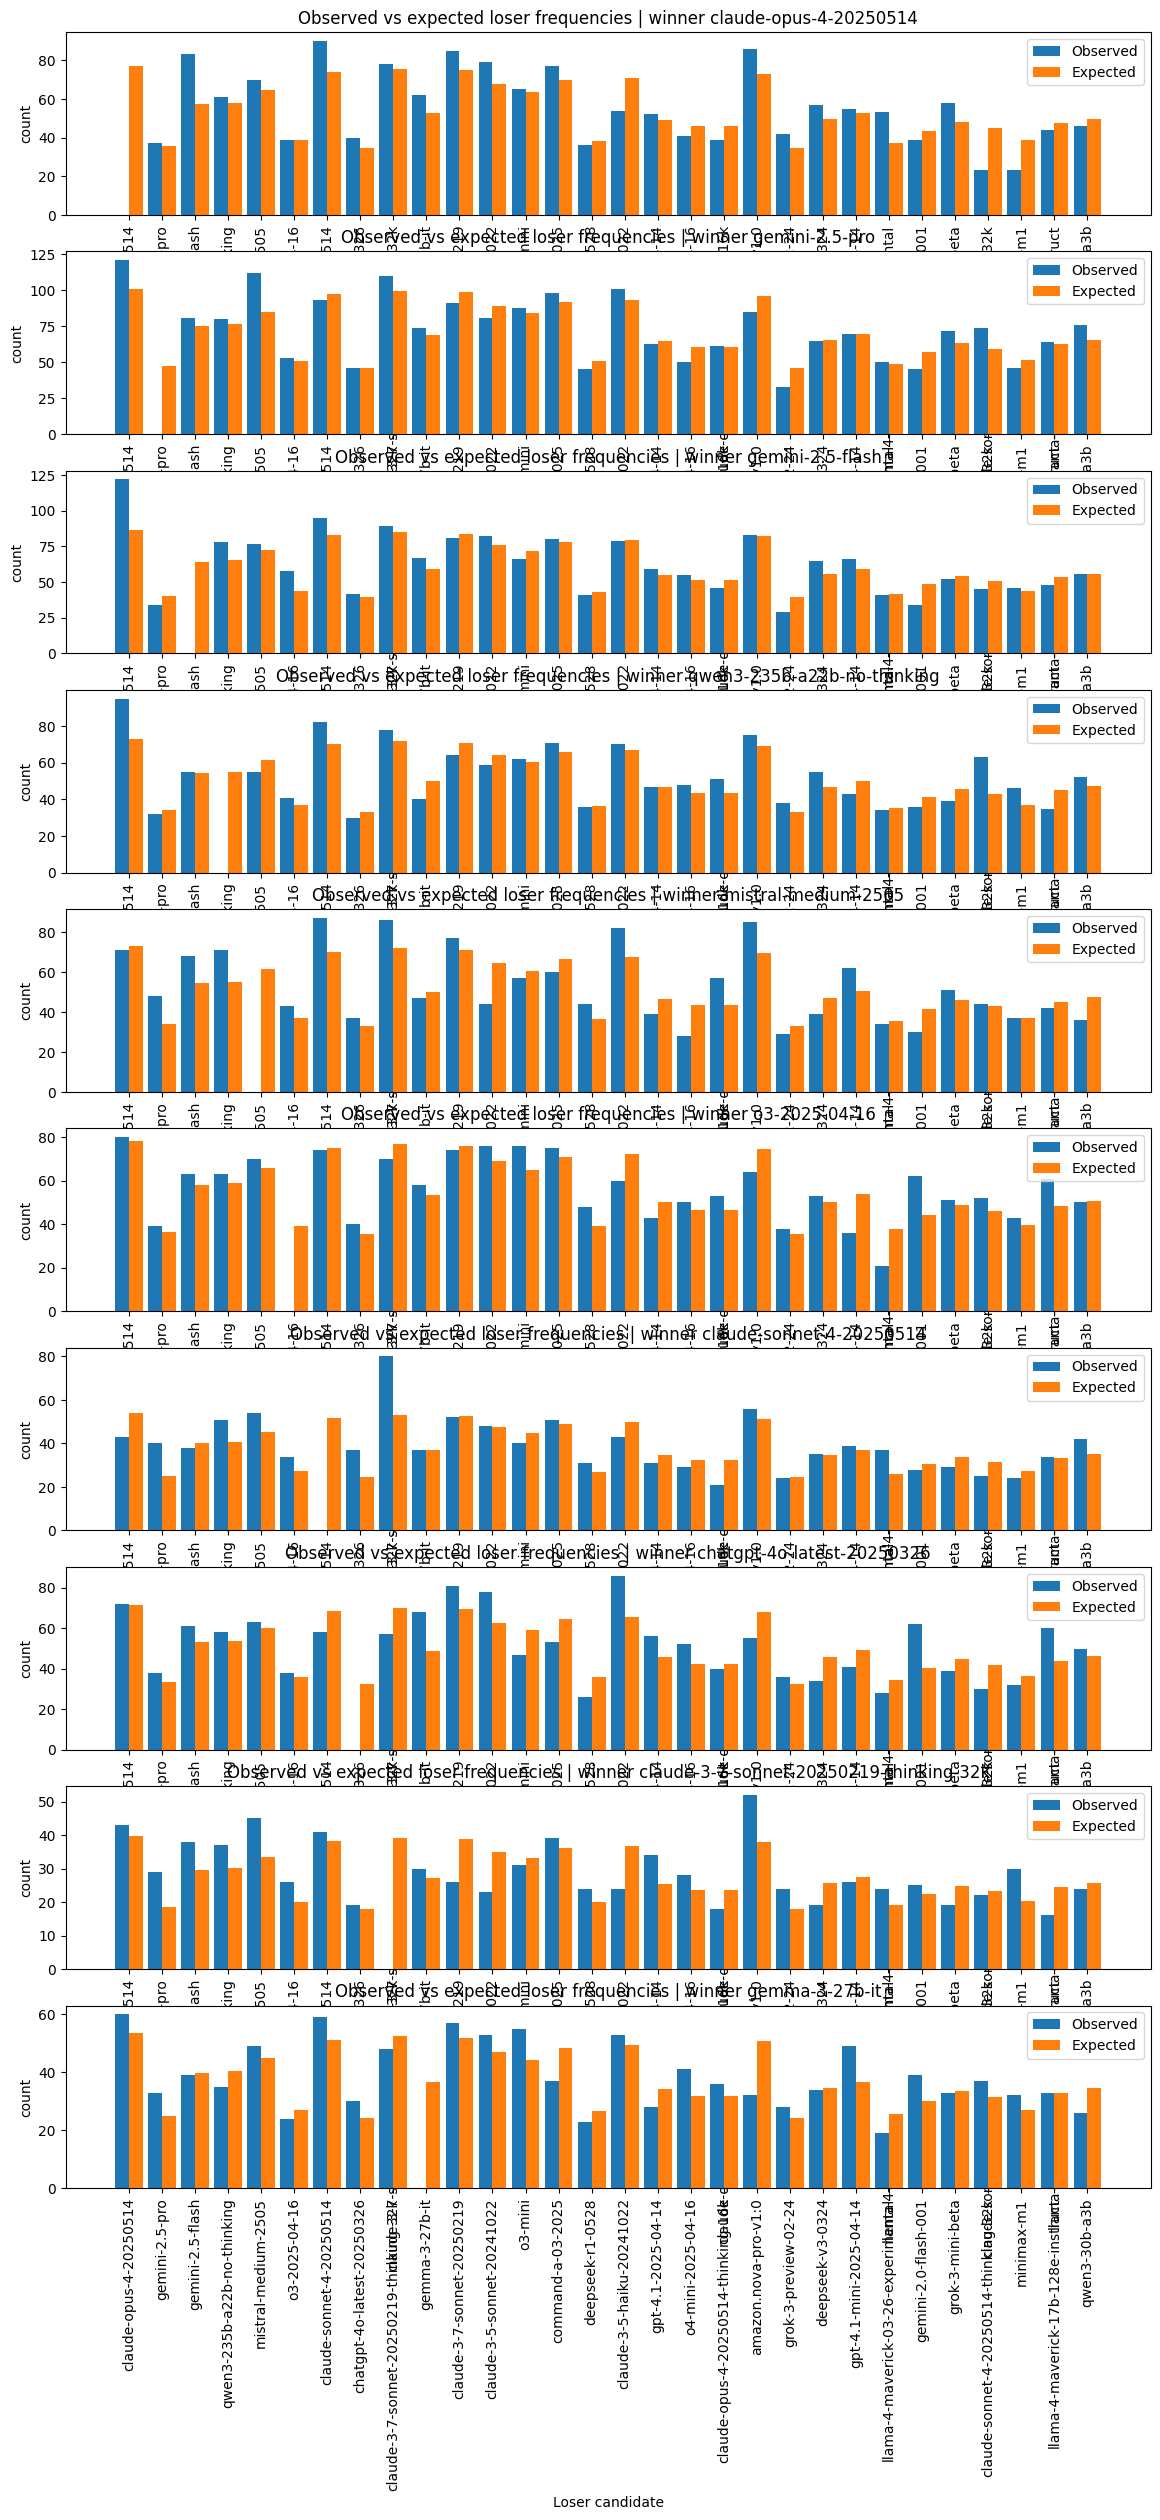

In [45]:
x = np.arange(observed.shape[1])
width = 0.42

fig, axes = plt.subplots(
    observed.shape[0],
    1,
    figsize=(14, max(3, 2.8 * observed.shape[0])),
    squeeze=False,
)

for row_idx, ax in enumerate(axes[:, 0]):
    ax.bar(x - width / 2, observed[row_idx], width=width, label='Observed')
    ax.bar(x + width / 2, expected[row_idx], width=width, label='Expected')
    ax.set_title(f'Observed vs expected loser frequencies | winner {observed_winner_labels[row_idx]}')
    ax.set_ylabel('count')
    ax.set_xticks(x)
    ax.set_xticklabels(observed_candidate_labels, rotation=90)
    ax.legend()

axes[-1, 0].set_xlabel('Loser candidate')
plt.tight_layout()
plt.show()


## Computing the conditional probability distributions

In [64]:
joint_counts = np.zeros(shape=(len(pw.candidate_distr), len(pw.candidate_distr)))
candidate_counts = np.zeros(shape=(len(pw.candidate_distr), ))
for p in range(len(pw.winners)):
    joint_counts[pw.winners[p], pw.losers[p]] += 1
    # joint_counts[pw.losers[p], pw.winners[p]] += 1
    candidate_counts[pw.winners[p]] += 1
    # candidate_counts[pw.losers[p]] += 1

In [65]:
joint_counts

array([[  0.,  37.,  83.,  61.,  70.,  39.,  90.,  40.,  78.,  62.,  85.,
         79.,  65.,  77.,  36.,  54.,  52.,  41.,  39.,  86.,  42.,  57.,
         55.,  53.,  39.,  58.,  23.,  23.,  44.,  46.],
       [121.,   0.,  81.,  80., 112.,  53.,  93.,  46., 110.,  74.,  91.,
         81.,  88.,  98.,  45., 101.,  63.,  50.,  61.,  85.,  33.,  65.,
         70.,  50.,  45.,  72.,  74.,  46.,  64.,  76.],
       [122.,  34.,   0.,  78.,  77.,  58.,  95.,  42.,  89.,  67.,  81.,
         82.,  66.,  80.,  41.,  79.,  59.,  55.,  46.,  83.,  29.,  65.,
         66.,  41.,  34.,  52.,  45.,  46.,  48.,  56.],
       [ 95.,  32.,  55.,   0.,  55.,  41.,  82.,  30.,  78.,  40.,  64.,
         59.,  62.,  71.,  36.,  70.,  47.,  48.,  51.,  75.,  38.,  55.,
         43.,  34.,  36.,  39.,  63.,  46.,  35.,  52.],
       [ 71.,  48.,  68.,  71.,   0.,  43.,  87.,  37.,  86.,  47.,  77.,
         44.,  57.,  60.,  44.,  82.,  39.,  28.,  57.,  85.,  29.,  39.,
         62.,  34.,  30.,  51., 

In [66]:
joint_distr = np.zeros_like(joint_counts)
for r in range(len(joint_counts)):
    joint_distr[r, ...] = joint_counts[r, ...] / candidate_counts[r] # joint_counts[r, ...].sum() # candidate_counts[r]

In [67]:
for r in range(len(joint_counts)):
    print(joint_counts[r, ...].sum())
    print(candidate_counts[r])

1614.0
1614.0
2128.0
2128.0
1816.0
1816.0
1532.0
1532.0
1535.0
1535.0
1643.0
1643.0
1133.0
1133.0
1499.0
1499.0
836.0
836.0
1122.0
1122.0
738.0
738.0
748.0
748.0
862.0
862.0
907.0
907.0
1273.0
1273.0
612.0
612.0
1071.0
1071.0
1083.0
1083.0
945.0
945.0
646.0
646.0
1229.0
1229.0
1022.0
1022.0
895.0
895.0
1106.0
1106.0
814.0
814.0
913.0
913.0
791.0
791.0
851.0
851.0
610.0
610.0
761.0
761.0


In [68]:
joint_distr[0]

array([0.        , 0.02292441, 0.05142503, 0.0377943 , 0.04337051,
       0.02416357, 0.05576208, 0.02478315, 0.04832714, 0.03841388,
       0.05266419, 0.04894672, 0.04027261, 0.04770756, 0.02230483,
       0.03345725, 0.03221809, 0.02540273, 0.02416357, 0.05328377,
       0.0260223 , 0.03531599, 0.03407683, 0.03283767, 0.02416357,
       0.03593556, 0.01425031, 0.01425031, 0.02726146, 0.02850062])

/tmp/ipykernel_2694667/3754164849.py:21: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


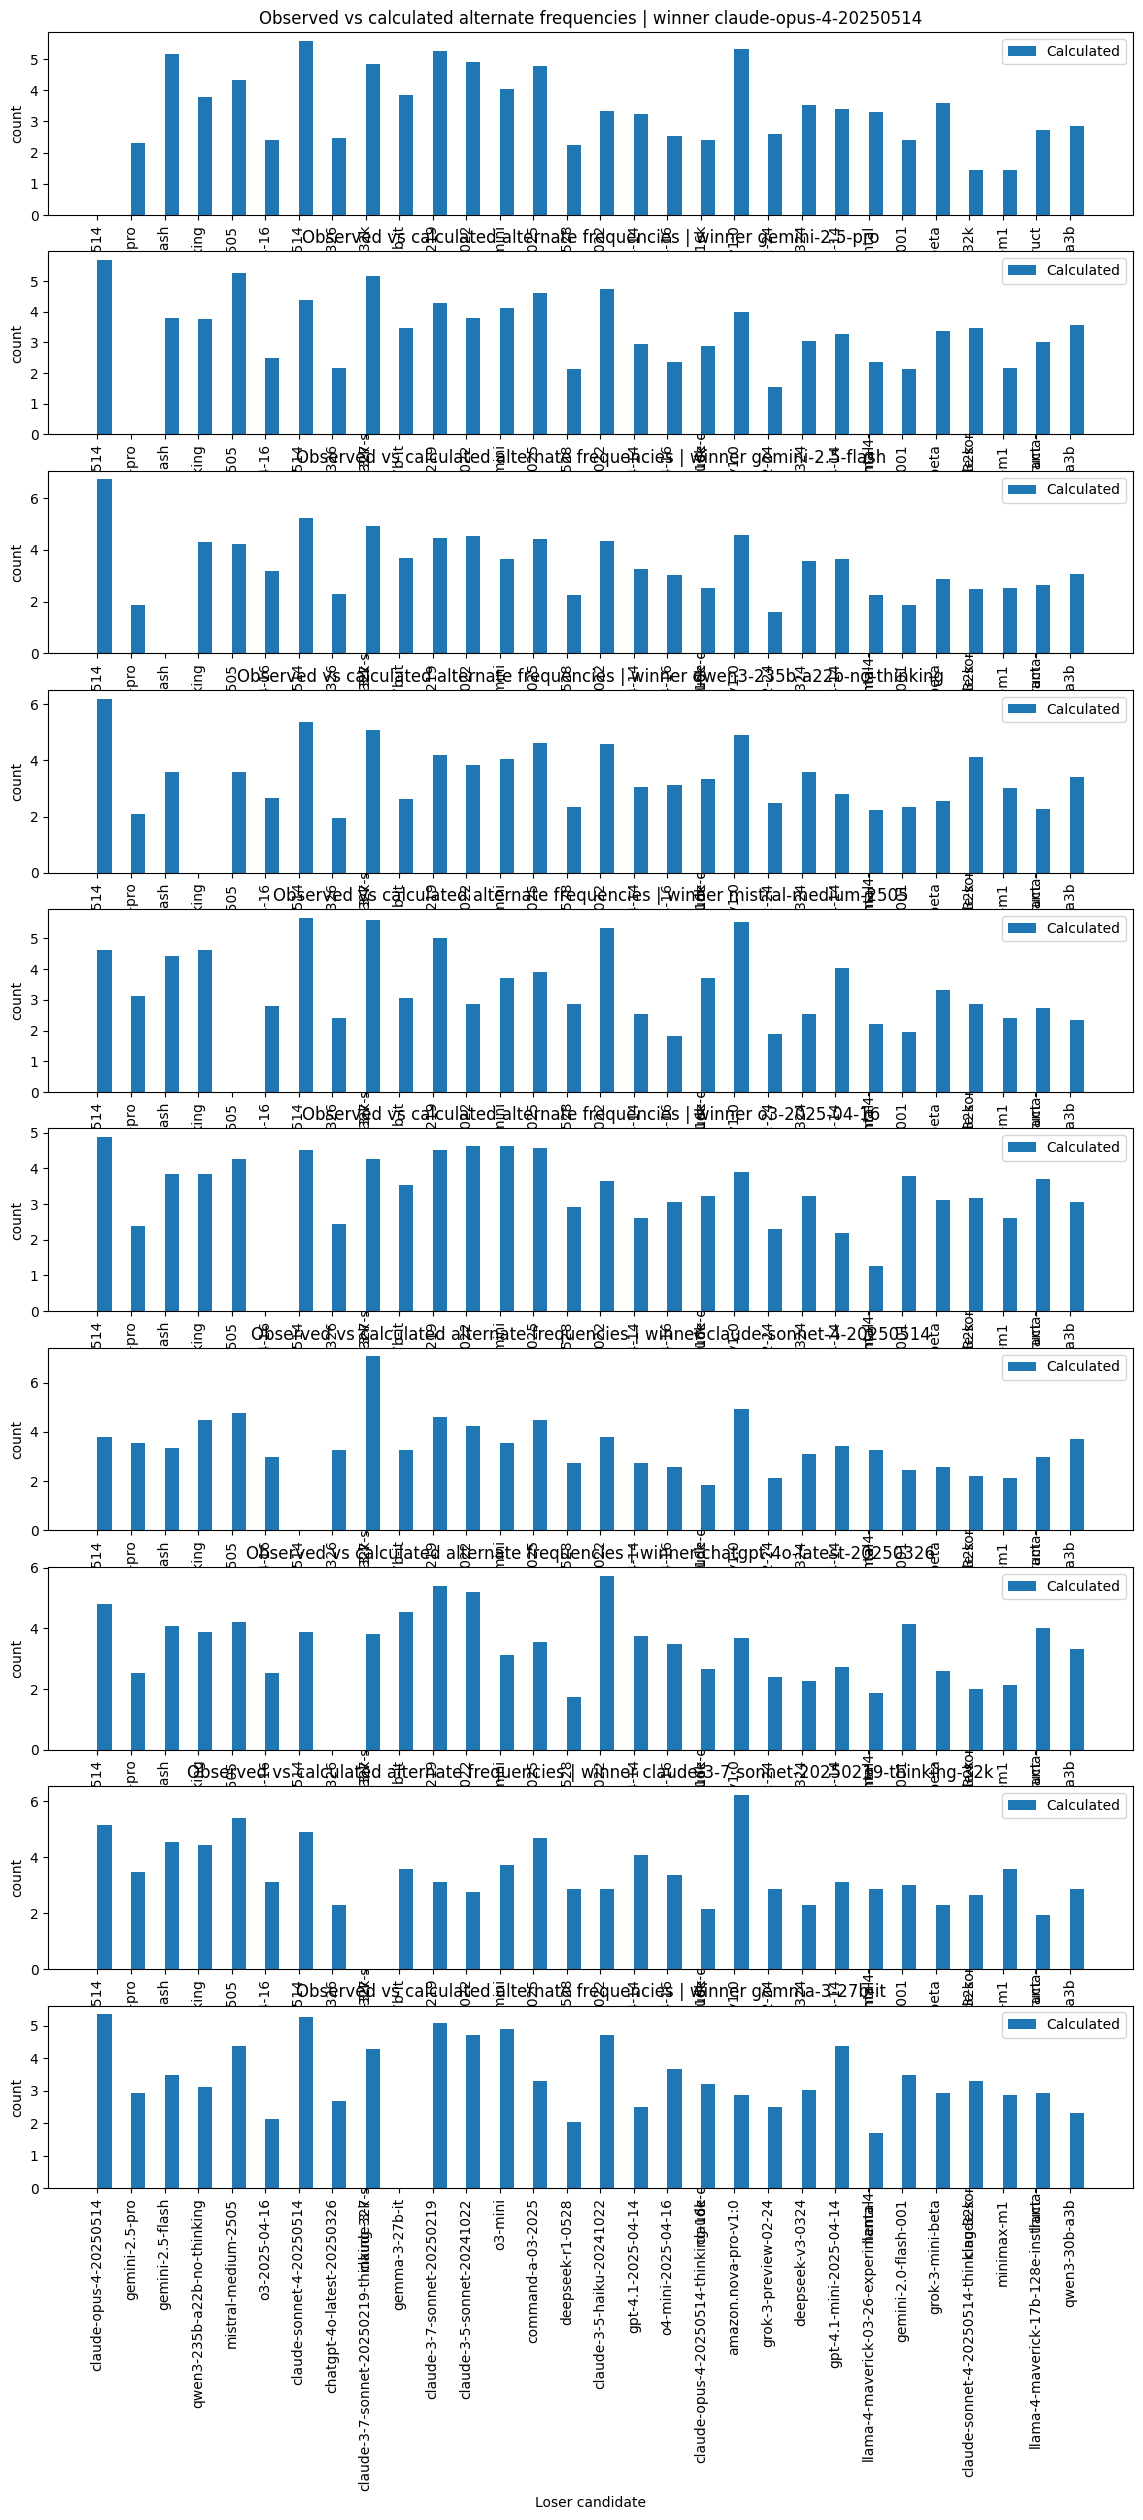

In [75]:
x = np.arange(observed.shape[1])
width = 0.42

fig, axes = plt.subplots(
    observed.shape[0],
    1,
    figsize=(14, max(3, 2.8 * observed.shape[0])),
    squeeze=False,
)

for row_idx, ax in enumerate(axes[:, 0]):
    # ax.bar(x - width / 2, observed[row_idx], width=width, label='Observed')
    ax.bar(x + width / 2, 100 * joint_distr[row_idx, ...], width=width, label='Calculated')
    ax.set_title(f'Observed vs calculated alternate frequencies | winner {observed_winner_labels[row_idx]}')
    ax.set_ylabel('count')
    ax.set_xticks(x)
    ax.set_xticklabels(observed_candidate_labels, rotation=90)
    ax.legend()

axes[-1, 0].set_xlabel('Loser candidate')
plt.tight_layout()
plt.show()


In [70]:
from scipy.special import expit

def borda_from_population_utilities(utilities, voter_dist=None, cand_dist=None, beta=1.0):
    utilities = np.asarray(utilities)
    V, C = utilities.shape

    if voter_dist is None:
        voter_dist = np.ones(V, dtype=float) / V
    else:
        voter_dist = np.asarray(voter_dist, dtype=float)
        assert voter_dist.shape == (V,)
        voter_dist = voter_dist / voter_dist.sum()

    if cand_dist is None:
        cand_dist = np.ones(C, dtype=float) / C
    else:
        cand_dist = np.asarray(cand_dist, dtype=float)
        # assert cand_dist.shape == (C,)
        # cand_dist = cand_dist / cand_dist.sum()

    P = np.zeros((C, C), dtype=float)

    for v, u in enumerate(utilities):
        diffs = u[:, None] - u[None, :]
        P += voter_dist[v] * expit(beta * diffs)

    np.fill_diagonal(P, 0.0) # remove this?
    borda_scores = (P * cand_dist).sum(axis=1) # (m, m) @ (m, ...)
    ranking = np.argsort(-borda_scores)

    return borda_scores, ranking

In [71]:
from utils_3 import leaderboard_dist

In [73]:
true_ranking = np.argsort(-population.avg_utilities)

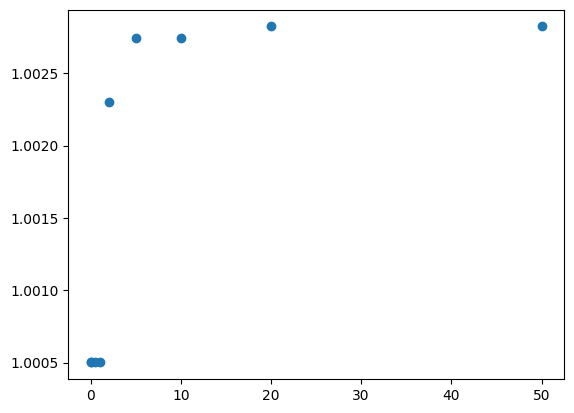

In [74]:
betas = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20, 50]
leaderboard_distortions = []

for beta in betas:
    borda_scores, borda_ranking = borda_from_population_utilities(utilities=population.population_utilities, voter_dist=population.voter_distr, cand_dist=joint_distr, beta=beta)
    distortion, k = leaderboard_dist(borda_ranking, true_ranking, population.avg_utilities)
    leaderboard_distortions.append(distortion)


plt.scatter(x=np.asarray(betas), y=np.asarray(leaderboard_distortions))
plt.show()